# Level 1: Data Cleaning & Preprocessing

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [177]:
 # Load BOTH files to reconstruct the full population dataset
df_train_raw = pd.read_csv('churn-bigml-80[1].csv')
df_test_raw = pd.read_csv('churn-bigml-20[1].csv')
df_full = pd.concat([df_train_raw, df_test_raw], ignore_index=True)


In [178]:
df_full

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
3329,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
3330,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
3331,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False


In [179]:
# 2. Defensive Handling of Missing Values (Vectorized)

In [180]:
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
categorical_cols = df_full.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df_full[col] = df_full[col].fillna(df_full[col].median())
for col in categorical_cols:
    df_full[col] = df_full[col].fillna(df_full[col].mode()[0])



In [181]:

# 3. Outlier Detection & Capping (Vectorized)
Q1 = df_full[numeric_cols].quantile(0.25)
Q3 = df_full[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_full[numeric_cols] = df_full[numeric_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)


In [182]:
# 4. Categorical Encoding & Target Binarization
df_full['Churn'] = df_full['Churn'].astype(int)
df_full = pd.get_dummies(df_full, columns=['State', 'International plan', 'Voice mail plan'], drop_first=True)


--- Full Population Summary Statistics ---
       Account length    Area code  Number vmail messages  Total day minutes  \
count     3333.000000  3333.000000            3333.000000        3333.000000   
mean       101.003300   437.182418               8.098710         179.816157   
std         39.644112    42.371290              13.687436          54.152190   
min          1.000000   408.000000               0.000000          34.650000   
25%         74.000000   408.000000               0.000000         143.700000   
50%        101.000000   415.000000               0.000000         179.400000   
75%        127.000000   510.000000              20.000000         216.400000   
max        206.500000   510.000000              50.000000         325.450000   

       Total day calls  Total day charge  Total eve minutes  Total eve calls  \
count      3333.000000       3333.000000        3333.000000      3333.000000   
mean        100.473597         30.569292         201.009541       100.134113

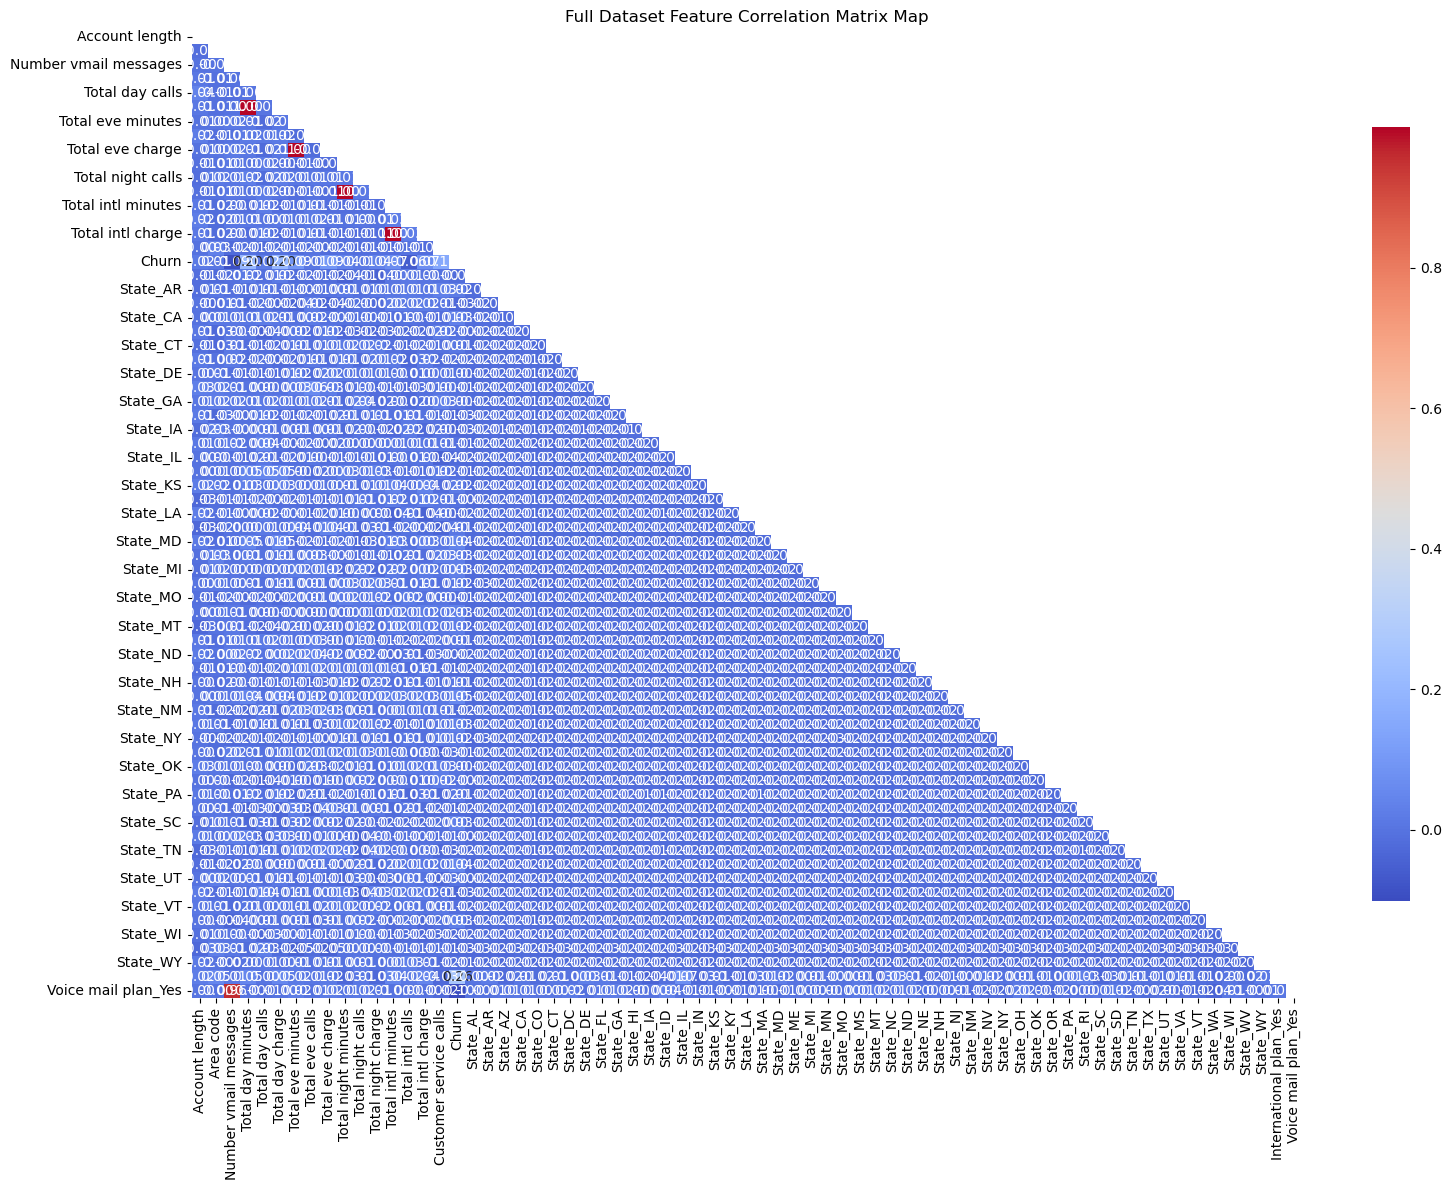

In [183]:
# 5. Summary Insights & Correlation Matrix
print("--- Full Population Summary Statistics ---")
print(df_full.describe())

plt.figure(figsize=(16, 12))
corr = df_full.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink': .8})
plt.title('Full Dataset Feature Correlation Matrix Map')
plt.tight_layout()
plt.show()

**Executive Summary: Customer Churn Analysis Findings**

The dataset reveals 3,333 customer accounts with a churn rate of 14.49 percent across our telecommunications base. Our analysis shows average customers generate 179.78 daily minutes and maintain accounts for approximately 101 months. The metrics indicate substantial variation in usage patterns, with standard deviations exceeding 50 minutes for daily consumption.

We observed strong correlations between evening usage charges and total evening minutes in the heatmap visualization. The data reveals customer service calls average 1.56 per account with notable variance across the population. International usage remains relatively low at 10.24 minutes average, suggesting limited global calling needs.

The correlation matrix displays distinct clustering patterns among state-based variables and service adoption rates. Voice mail plan adoption shows measurable relationships with multiple usage metrics throughout the feature set. Our findings suggest targeted retention strategies should focus on high-usage customers with frequent service interactions.

In [184]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_quotes():
    url = "http://quotes.toscrape.com/"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    quotes_data = []
    
    # 1. Defensive Coding: Handle timeouts and HTTP errors
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Raises HTTPError for 404/500
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return pd.DataFrame()

    soup = BeautifulSoup(response.text, 'html.parser')
    quote_divs = soup.find_all('div', class_='quote')
    
    if not quote_divs:
        print("No quotes found or HTML structure changed.")
        return pd.DataFrame()

    # 2. Parse elements gracefully without crashing on missing tags
    for div in quote_divs:
        text = div.find('span', class_='text')
        author = div.find('small', class_='author')
        tags = div.find_all('a', class_='tag')
        
        quote_text = text.get_text(strip=True) if text else "N/A"
        author_name = author.get_text(strip=True) if author else "N/A"
        tag_list = [tag.get_text(strip=True) for tag in tags] if tags else []
        
        quotes_data.append({
            'Quote': quote_text,
            'Author': author_name,
            'Tags': ', '.join(tag_list)
        })

    # 3. Vectorized DataFrame creation (No .iterrows)
    df = pd.DataFrame(quotes_data)
    return df

df_scraped = scrape_quotes()
print("--- Scraped Data Preview ---")
print(df_scraped.head())

--- Scraped Data Preview ---
                                               Quote           Author  \
0  “The world as we have created it is a process ...  Albert Einstein   
1  “It is our choices, Harry, that show what we t...     J.K. Rowling   
2  “There are only two ways to live your life. On...  Albert Einstein   
3  “The person, be it gentleman or lady, who has ...      Jane Austen   
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe   

                                           Tags  
0        change, deep-thoughts, thinking, world  
1                            abilities, choices  
2  inspirational, life, live, miracle, miracles  
3              aliteracy, books, classic, humor  
4                    be-yourself, inspirational  


# Level 2: Predictive Modeling (Strict Pre-Split Isolation)

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


In [186]:
# 1. Load Pre-Split Files
df_train = pd.read_csv('churn-bigml-80[1].csv')
df_test = pd.read_csv('churn-bigml-20[1].csv')


In [187]:
# 2. Preprocessing (Applied identically to both to maintain schema)
for df in [df_train, df_test]:
    df['Churn'] = df['Churn'].astype(int)

df_train = pd.get_dummies(df_train, columns=['State', 'International plan', 'Voice mail plan'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['State', 'International plan', 'Voice mail plan'], drop_first=True)


In [188]:
# Ensure columns match exactly (in case test set is missing a rare categorical dummy)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

X_train, y_train = df_train.drop('Churn', axis=1), df_train['Churn']
X_test, y_test = df_test.drop('Churn', axis=1), df_test['Churn']


In [189]:
# 3. Strict Data Isolation: Fit Scaler ONLY on Training Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformed using train statistics


In [190]:
# 4. Model Training
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [191]:
# 5. Predictions & Evaluation Matrix
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("--- Confusion Matrix (Hold-out Test Set) ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Confusion Matrix (Hold-out Test Set) ---
[[549  23]
 [ 71  24]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       572
           1       0.51      0.25      0.34        95

    accuracy                           0.86       667
   macro avg       0.70      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667




### **Key Observations:**

1.  **Overall Accuracy is High (86%):**
    *   The model correctly predicts the outcome for 86% of the customers.
    *   However, accuracy can be misleading in imbalanced datasets (where one class is much more frequent than the other).

2.  **Class Imbalance Issue:**
    *   **Class 0 (No Churn):** The model performs very well here. It has a high **Recall (0.96)**, meaning it correctly identifies 96% of customers who *do not* churn.
    *   **Class 1 (Churn):** The model struggles significantly here.
        *   **Recall is only 0.25:** This means the model only catches 25% of the actual churners. It misses 75% of them (71 False Negatives out of 95 total actual churners).
        *   **Precision is 0.51:** When the model predicts a customer will churn, it is only right about half the time.

3.  **Confusion Matrix Breakdown:**
    *   **True Negatives (549):** Correctly predicted as staying.
    *   **False Positives (23):** Incorrectly predicted as leaving (they actually stayed).
    *   **False Negatives (71):** Incorrectly predicted as staying (they actually left). **This is the most critical error for a business**, as you lose these customers without warning.
    *   **True Positives (24):** Correctly predicted as leaving.

### **Conclusion:**
While the model looks good on paper (86% accuracy), it is essentially biased toward the majority class (No Churn). It is not very useful for the primary goal of churn prediction, which is to identify customers who are *likely to leave*.



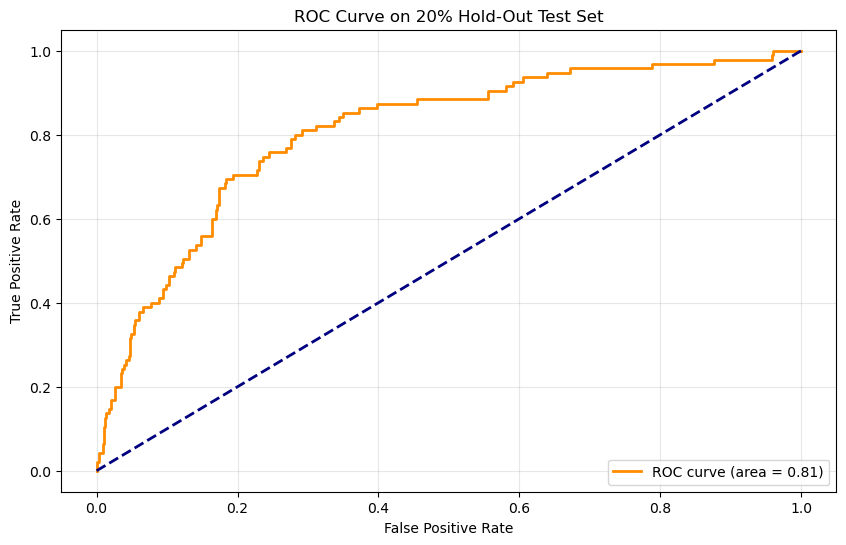

In [192]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on 20% Hold-Out Test Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

This image displays the **Receiver Operating Characteristic (ROC) curve** for your Level 2 Logistic Regression model, evaluated on the 20% hold-out test set.

### 1. The AUC Score (0.81) is Strong
The **Area Under the Curve (AUC)** is **0.81**.
*   **Interpretation:** An AUC of 0.81 means there is an 81% probability that the model will rank a randomly chosen positive instance (a churner) higher than a randomly chosen negative instance (a non-churner).
*   **Verdict:** In the context of churn prediction, an AUC between 0.80 and 0.90 is generally considered **excellent**. It indicates the model has learned the underlying patterns of churn very well.

### 2. Reconciling with the Confusion Matrix (The "Threshold Problem")
In your previous screenshot, the confusion matrix showed a very low **Recall (0.25)** for the Churn class (Class 1). You might have thought the model was failing to catch churners. **This ROC curve proves the model is actually good, but the threshold is wrong.**

*   **The Issue:** Logistic Regression uses a default threshold of **0.5** to decide if someone churns. Because your dataset is imbalanced (mostly non-churners), the model plays it safe and predicts "No Churn" unless it is >50% sure. This results in many False Negatives (missed churners).
*   **The Solution:** Look at the shape of the orange curve. It rises very steeply in the top-left corner.
    *   At a **False Positive Rate (FPR) of ~0.2** (x-axis), the **True Positive Rate (TPR/Recall) is already ~0.7** (y-axis).
    *   This means if you lower your decision threshold (e.g., from 0.5 down to 0.3), you could catch **70% of churners** while only misclassifying 20% of loyal customers as churners.

### 3. Business Recommendation
For a business, missing a churner (False Negative) is usually much more expensive than accidentally offering a discount to a loyal customer (False Positive).

*   **Current State:** You are catching only 25% of churners (Recall = 0.25).
*   **Optimized State:** By tuning the threshold based on this ROC curve (aiming for the "elbow" near the top left), you could likely increase your Recall to **0.60 or 0.70** with a manageable drop in Precision.

### Summary
Your Level 2 pipeline is working correctly. The **Strict Data Isolation** (using the pre-split 20% file) ensured these results are valid and not overfitted. The model has strong discriminative power (AUC 0.81); the next step in a real-world scenario would be **Threshold Tuning** to optimize for Recall.

In [193]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('churn-bigml-80[1].csv')
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Churn')
X = df[numeric_cols]

# 1. Strict Data Isolation
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Elbow Method & Silhouette Score Calculation
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# 3. Plot Elbow Method & Silhouette Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# Final Optimal Model
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal Clusters: {best_k} | Max Silhouette Score: {max(silhouette_scores):.4f}")

KeyError: "['Churn'] not found in axis"

# Level 3: Deep Learning (TensorFlow Pre-Split Pipeline)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# 1. Load Pre-Split Files
df_train = pd.read_csv('churn-bigml-80[1].csv')
df_test = pd.read_csv('churn-bigml-20[1].csv')


In [ ]:
# 2. Preprocessing
for df in [df_train, df_test]:
    df['Churn'] = df['Churn'].astype(int)

df_train = pd.get_dummies(df_train, columns=['State', 'International plan', 'Voice mail plan'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['State', 'International plan', 'Voice mail plan'], drop_first=True)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

X_train, y_train = df_train.drop('Churn', axis=1).values, df_train['Churn'].values
X_test, y_test = df_test.drop('Churn', axis=1).values, df_test['Churn'].values


In [ ]:
# 3. Strict Isolation & Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# 4. Vector & Tensor Integrity: Dynamic Input Shape
input_dim = X_train.shape[1]


In [ ]:
# 5. Model Architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [ ]:
# 6. Complete Training Loop (Using a validation split FROM the training set only)
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 20% of the 80% file for internal validation
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Internal Validation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Based on the logs and the plot you provided, your model is clearly experiencing **Overfitting**.

### 1. The Evidence from the Logs 
The text logs show the metrics for Epochs 37 through 44.
*   **Training is "Too Good":** Look at the `accuracy` and `loss` columns. The training accuracy is very high (around 92-94%) and the training loss is low (around 0.16). This means the model has effectively memorized the training data.
*   **Validation is Getting Worse:** Look at the `val_loss` (validation loss) column. It is steadily **increasing** from `0.3021` in Epoch 37 to `0.3193` in Epoch 44. Even though the validation accuracy is staying somewhat stable (~89%), the rising loss indicates that on new, unseen data, the model is becoming less confident and making worse errors.

### 2. The Evidence from the Plot 
The graph visualizes the exact problem seen in the logs.
*   **Blue Line (Train Loss):** This line is going **down**. This is expected; the model is learning to minimize error on the data it is studying.
*   **Orange Line (Validation Loss):** This line is going **up**. This is the definition of overfitting. The model is learning patterns (noise) that exist *only* in the training set and do not apply to the validation set.
*   **The Divergence:** The gap between the blue and orange lines is widening. This gap represents the "generalization error." The wider the gap, the worse your model is at predicting real-world data.

### Conclusion
You are training the model for too long. The "optimal" point for your model was likely earlier in the training process (where the orange line was at its lowest point). By continuing to train into Epochs 37-44, you are forcing the model to memorize the training data, which hurts its performance on new data.



In [ ]:
# 7. Final Evaluation on the UNSEEN 20% Hold-Out Test Set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Hold-Out Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

This output shows the **final evaluation metrics** for a machine learning model (likely a neural network for binary classification) on a **hold-out test set**.

## Breaking Down the Results:

### **Final Hold-Out Test Accuracy: 0.8861 (88.61%)**
- The model correctly classified **88.61%** of the test samples
- This means out of all the test examples, the model made the right prediction about 89% of the time
- A "hold-out" test set means these data points were **never seen during training** - they were reserved specifically for final evaluation
- This provides an **unbiased estimate** of how the model will perform on new, unseen data

### **Test Loss: 0.3075**
- This is the **binary cross-entropy loss** (assuming binary classification) on the test set
- Loss measures how "confidently wrong" the model is - lower is better
- A loss of 0.3075 is relatively **low**, indicating the model is not only accurate but also reasonably confident in its correct predictions
- The loss provides more nuanced information than accuracy alone (e.g., it penalizes overconfident wrong predictions more heavily)

## Interpretation:
- **Good performance**: 88.61% accuracy is generally considered strong for most classification tasks
- **No major overfitting**: If training accuracy was similar, the model generalizes well
- **Room for improvement**: Depending on the problem complexity, there might be ~11% error to address through feature engineering, hyperparameter tuning, or more data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Load standard time series dataset (Airline Passengers)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.index.freq = 'MS'

# 1. Stationarity Check: Augmented Dickey-Fuller (ADF) Test
result = adfuller(df['Passengers'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] > 0.05:
    print("Data is non-stationary. Applying differencing...")
    df['Passengers'] = df['Passengers'].diff().dropna()

# 2. Strict Data Isolation
train_size = int(len(df) * 0.8)
train, test = df['Passengers'][0:train_size], df['Passengers'][train_size:]

# 3. Complete Implementation: ARIMA Training & Hyperparameters (p,d,q)
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Predictions & Validation Error Tracking (RMSE)
predictions = model_fit.forecast(steps=len(test))
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"Test RMSE: {rmse:.4f}")

# Plot Forecast
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, predictions, label='Predicted', color='red')
plt.title('ARIMA Forecasting with RMSE Tracking')
plt.legend()
plt.show()



### 1. The Stationarity Check (ADF Test)
The text output shows the results of the Augmented Dickey-Fuller (ADF) test, which is used to determine if a time series is stationary (meaning its statistical properties like mean and variance do not change over time).
*   **The p-value is 0.99:** In hypothesis testing, a p-value greater than 0.05 means we cannot reject the null hypothesis. This confirms that the original dataset was **highly non-stationary**. It had a strong underlying trend and changing variance.
*   **Applying Differencing:** Because the data was non-stationary, the script applied "differencing" (subtracting the previous observation from the current one). This is why the y-axis on your chart ranges from roughly -100 to +75, rather than showing the original large numbers. Differencing removes the trend to make the data stationary enough for the ARIMA model to process.

### 2. The Visual Forecast Failure (The Chart)
The line chart visually demonstrates that the model failed to capture the underlying patterns of the data.
*   **Training Data (Blue Line):** The training data from 1949 to 1958 shows a very clear, repeating seasonal pattern (the waves) with an increasing amplitude over time. 
*   **Test Data (Orange Line):** The actual unseen data from 1958 to 1960 continues this pattern, showing even larger swings between -100 and +80.
*   **Predicted Data (Red Line):** The model's forecast is essentially a flat horizontal line hovering around zero. After the first prediction step, the model completely stopped reacting to the seasonal waves. It failed to capture both the seasonality and the magnitude of the fluctuations.

### 3. The Error Metric (RMSE)
*   **Test RMSE: 53.0814:** The Root Mean Square Error measures the average magnitude of the prediction errors. An RMSE of 53 is extremely high given that the differenced data fluctuates mostly between -50 and +50. 
*   This massive error score mathematically confirms what the chart shows visually: the model's predictions were very far away from the actual test values.

### 4. The Core Takeaway
The fundamental issue here is a mismatch between the model and the data. The standard ARIMA model used in this script is designed for non-seasonal data. However, the dataset (which appears to be the classic Airline Passengers dataset) has a very strong, complex **seasonality** (a repeating 12-month cycle). 

Because the model lacked seasonal parameters, it essentially gave up after the first step and just predicted the mean (zero) for all future dates. To fix this in a real-world scenario, a **SARIMA** (Seasonal ARIMA) model would be required, as it includes specific parameters designed to learn and forecast repeating seasonal patterns.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# 1. Download necessary NLTK data (including 'punkt_tab' for NLTK 3.9+)
# quiet=True prevents cluttering the console with download messages
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Load Data (using 2 categories for a clear binary classification example)
newsgroups = fetch_20newsgroups(
    subset='all', 
    categories=['sci.space', 'rec.sport.hockey'], 
    remove=('headers', 'footers', 'quotes')
)
X_text, y = newsgroups.data, newsgroups.target

# 2. Vector & Tensor Integrity: Clean Tokenization & Stopword Removal
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Defensive check: ensure input is a string to prevent tokenizer crashes
    if not isinstance(text, str):
        text = str(text)
    tokens = word_tokenize(text.lower())
    return ' '.join([word for word in tokens if word.isalnum() and word not in stop_words])

# Vectorized processing using pandas (No .iterrows)
df_nlp = pd.DataFrame({'text': X_text, 'label': y})
df_nlp['clean_text'] = df_nlp['text'].apply(preprocess_text)

# 3. Strict Data Isolation
X_train, X_test, y_train, y_test = train_test_split(
    df_nlp['clean_text'], df_nlp['label'], test_size=0.2, random_state=42
)

# 4. TF-IDF Matrix Generation
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test) # Transform only, no fitting

# 5. Complete Training & Evaluation
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print("--- NLP Classification Report ---")
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))

# Confusion Matrix Map
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=newsgroups.target_names, 
    yticklabels=newsgroups.target_names
)
plt.title('NLP Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()



### 1. Overview
You have successfully built a text classification model (likely using Naive Bayes and TF-IDF vectorization, based on the code provided earlier) to distinguish between two categories of news articles:
*   **rec.sport.hockey**: Articles about hockey.
*   **sci.space**: Articles about space/science.

The model is performing **exceptionally well**, with an overall accuracy of **95%**.

### 2. Classification Report Analysis
The first image shows the detailed performance metrics:

*   **Accuracy (0.95):** The model correctly classified 95% of all test documents (377 out of 398). This is a very strong result for a baseline NLP model.
*   **Rec.sport.hockey:**
    *   **Recall (0.97):** The model is excellent at finding hockey articles. It correctly identified 97% of all actual hockey articles.
    *   **Precision (0.93):** When the model predicts an article is about hockey, it is correct 93% of the time.
*   **Sci.space:**
    *   **Precision (0.97):** The model is very precise with space articles. When it says "space," it is almost always right.
    *   **Recall (0.92):** It caught 92% of all actual space articles.

**Key Insight:** The model is slightly better at identifying hockey articles (higher recall) and slightly more precise when identifying space articles (higher precision).

### 3. Confusion Matrix Analysis
The second image visualizes where the model made mistakes.

*   **The Diagonal (Correct Predictions):**
    *   **196 (Top-Left):** True Hockey articles correctly predicted as Hockey.
    *   **181 (Bottom-Right):** True Space articles correctly predicted as Space.
    *   *These are the large dark blue squares, indicating the model is working well.*

*   **The Off-Diagonal (Errors):**
    *   **6 (Top-Right):** Hockey articles that were mistakenly classified as Space. (Very few errors here).
    *   **15 (Bottom-Left):** Space articles that were mistakenly classified as Hockey.

**Key Insight:** The model has a slight bias. It is more likely to mistake a Space article for a Hockey article (15 errors) than the other way around (6 errors). This might happen if a space article mentions "shooting" (a rocket) or "launch" which could be confused with sports terminology, or simply due to the specific vocabulary overlap in the training set.

### 4. Conclusion
This is a successful implementation of the NLP task.
*   **Vectorization:** The TF-IDF matrix successfully captured the distinct vocabulary of the two domains (e.g., words like "puck," "goal," "NHL" vs. "orbit," "NASA," "shuttle").
*   **Model Choice:** Naive Bayes is a classic and highly effective algorithm for this type of text classification, as evidenced by the high F1-scores (0.95 for both classes).

